# Structure Tensor vs. Nematic Tensor

### Gradient and pixel orientation

Let $f(\mathbf x)$, $\mathbf x=(x,y)$, be the image, $\mathbf g=\nabla f$ its gradient (central finite differences) and $\mathbf n=\mathbf g/\|\mathbf g\|$. The orientation of a pixel is perpendicular to the gradient,

$$\theta=\operatorname{atan2}(g_y,g_x)+90^\circ \pmod{180^\circ}.$$

It is an axis: $\theta$ and $\theta+180^\circ$ are the same orientation.

### Estimators

All three estimators use the same Gaussian local average

$$\langle h\rangle(\mathbf x)=\sum_{\mathbf y} w(\mathbf x-\mathbf y)\,h(\mathbf y),\qquad w(\mathbf x)\propto\exp\!\big(-\|\mathbf x\|^2/2\sigma_{\mathrm{agg}}^2\big).$$

- **naive**: $\hat\theta_{\mathrm{naive}}=\langle\theta\rangle$, the arithmetic mean of $\theta\in[0^\circ,180^\circ)$;
- **nematic tensor** $Q=\langle\mathbf n\mathbf n^{\mathsf T}\rangle$: every pixel has weight 1;
- **structure tensor** $J=\langle\mathbf g\mathbf g^{\mathsf T}\rangle=\langle\|\mathbf g\|^2\,\mathbf n\mathbf n^{\mathsf T}\rangle$: every pixel has weight $\|\mathbf g\|^2$.

For $M\in\{Q,J\}$, $\hat\theta=\tfrac12\operatorname{atan2}(2M_{xy},\,M_{xx}-M_{yy})+90^\circ$. The confidence is the nematic order $S$ for $Q$ and the coherency $C=(\lambda_1-\lambda_2)/(\lambda_1+\lambda_2)$ for $J$. The energy is $E=\operatorname{tr}J=\langle\|\mathbf g\|^2\rangle$.

### Test image

$$f_0(\mathbf x)=A\,\operatorname{clip}\!\Big(\gamma_{\mathrm{sat}}\,w_{\mathrm{ring}}(r)\,\sin\frac{2\pi r}{T},\,-1,\,1\Big)+\beta_{\mathrm{ramp}}\,(c_y-y),\qquad r=\|\mathbf x-\mathbf c\|.$$

Concentric sine rings of amplitude $A=0.5$ and period $T=20$ px, restricted to an annulus ($70\le r\le175$ px) by the window $w_{\mathrm{ring}}$. The ring gradient is radial, so the **reference orientation** is tangential: $\theta_{\mathrm{ref}}=\operatorname{atan2}(y-c_y,\,x-c_x)+90^\circ$.

Degradations:
- **saturation**: gain $\gamma_{\mathrm{sat}}$ and clipping at $\pm1$. The saturated regions are flat, with zero ring gradient. The level is the ratio of saturated pixels $\rho_{\mathrm{sat}}=1-\tfrac{2}{\pi}\operatorname{asin}(1/\gamma_{\mathrm{sat}})$.
- **ramp**: vertical intensity ramp of slope $\beta_{\mathrm{ramp}}$, of orientation $0^\circ$.
- **Gaussian noise**: standard deviation $\sigma_{\mathrm{noise}}$, SNR $=(A^2/2)/\sigma_{\mathrm{noise}}^2$.
- **shot noise** (Poisson): $f_0\leftarrow\lambda_{\mathrm{shot}}\,k+f_{\min}$ with $k\sim\operatorname{Poisson}\big((f_0-f_{\min})/\lambda_{\mathrm{shot}}\big)$. The variance, $\lambda_{\mathrm{shot}}(f_0-f_{\min})$, is larger on the bright side of the ramp.
- **speckle noise** (salt and pepper): a ratio $\rho_{\mathrm{sp}}$ of the pixels is set to the maximum or the minimum of $f_0$.

### Degradation levels

A degradation that is not varied stays at its baseline (bold).

| degradation | parameter | none | low | medium | high | section |
|---|---|---|---|---|---|---|
| saturation | $\rho_{\mathrm{sat}}$ | 0 | **0.4** | 0.6 | 0.8 | 2 |
| Gaussian noise | $\sigma_{\mathrm{noise}}$ | 0 | **0.005** | 0.015 | 0.025 | 3 |
| ramp | $\beta_{\mathrm{ramp}}$ | 0 | **0.01** | 0.02 | 0.05 | 4 |
| shot noise | $\lambda_{\mathrm{shot}}$ | **0** | 0.005 | 0.05 | 0.5 | 5 |
| speckle noise | $\rho_{\mathrm{sp}}$ | **0** | 0.002 | 0.01 | 0.02 | 6 |

### Aggregation window

$\sigma_{\mathrm{agg}}=7$ px, varied in Section 7.

### Evaluation mask

The flat part of the annulus, $w_{\mathrm{ring}}=1$, outlined in magenta. It contains every orientation equally, so the reference histogram is flat.

### Angular error

The axial difference $\hat\theta-\theta_{\mathrm{ref}}$, wrapped to $[-90^\circ,90^\circ)$. The MAE is its mean absolute value over the mask.

In [102]:
%load_ext autoreload
%autoreload 2
import importlib, ring_experiment_lib
importlib.reload(ring_experiment_lib)         # always pick up the current module, including new names
from ring_experiment_lib import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [103]:
# ============================================================
# User parameters: degradation levels (edit here)
# ============================================================
LEVELS = ('none', 'low', 'medium', 'high')
SATURATION_RATIO = {'none': 0.0, 'low': 0.4,   'medium': 0.6,   'high': 0.8}     # ρ_sat: ratio of saturated pixels, in [0, 1)
NOISE            = {'none': 0.0, 'low': 0.005, 'medium': 0.015, 'high': 0.025}   # σ_noise: std of the Gaussian noise
RAMP             = {'none': 0.0, 'low': 0.01,  'medium': 0.02,  'high': 0.05}    # β_ramp: slope of the ramp
SHOT             = {'none': 0.0, 'low': 0.005,  'medium': 0.05,  'high': 0.5}    # λ_shot: intensity of one photon (Poisson)
SPECKLE          = {'none': 0.0, 'low': 0.002, 'medium': 0.01,  'high': 0.02}    # ρ_sp: ratio of salt-and-pepper pixels

# level of each degradation when it is not the one being varied (Sections 2-7);
# Section 1 sets saturation, noise and ramp to the same level and keeps shot noise and speckle at their baseline
BASELINE = {'saturation': 'low', 'noise': 'low', 'ramp': 'low', 'shot': 'none', 'speckle': 'none'}

LEVEL_TITLES = {'none': 'Clean rings', 'low': 'Low degradation', 'medium': 'Medium degradation', 'high': 'High degradation'}


def degraded_image(level=None, **levels):
    """Ring image with each degradation at a level name. `level` sets saturation, noise and ramp together;
    keyword arguments (saturation=, noise=, ramp=, shot=, speckle=) set single degradations; the others are at BASELINE."""
    chosen = dict(BASELINE)
    if level is not None:
        chosen.update(saturation=level, noise=level, ramp=level)
    chosen.update(levels)
    return make_ring_image(SATURATION_RATIO[chosen['saturation']], NOISE[chosen['noise']], RAMP[chosen['ramp']],
                           SHOT[chosen['shot']], SPECKLE[chosen['speckle']])


print(f"{'':12s}" + ''.join(f'{level:>10s}' for level in LEVELS) + '    baseline')
for name, table, key in (('ρ_sat', SATURATION_RATIO, 'saturation'), ('σ_noise', NOISE, 'noise'),
                         ('β_ramp', RAMP, 'ramp'), ('λ_shot', SHOT, 'shot'), ('ρ_sp', SPECKLE, 'speckle')):
    print(f'{name:12s}' + ''.join(f'{table[level]:>10g}' for level in LEVELS) + f'    {BASELINE[key]}')

                  none       low    medium      high    baseline
ρ_sat                0       0.4       0.6       0.8    low
σ_noise              0     0.005     0.015     0.025    low
β_ramp               0      0.01      0.02      0.05    low
λ_shot               0     0.005      0.05       0.5    none
ρ_sp                 0     0.002      0.01      0.02    none


In [104]:
# ============================================================
# Figure settings and figure functions: edit here to change the rendering
# ============================================================
FONTSIZE = {'base': 24, 'title': 26, 'label': 25, 'tick': 22, 'legend': 30, 'suptitle': 36, 'mae': 23}
PAD = {'w_pad': 0.0, 'h_pad': 0.08}          # space between panels [inches]
HISTOGRAM_YLIM = (0, 800)                    # y-range of the orientation histograms [pixels per bin]; flat reference ≈ 247
FIGSIZE_MAPS = (26, 15)                      # Section 1, maps: 2 rows x 4 columns
FIGSIZE_HISTOGRAMS = (30, 8.5)               # Section 1, histograms: 1 row x 4 columns
FIGSIZE_SWEEP = (24.8, 20)                   # Sections 2-5: 4 columns; rows = images, histograms, statistics
SWEEP_HEIGHT_RATIOS = (1.15, 1.0, 1.0)       # relative heights of the three rows of the sweep figures
MARKERS = {'mean': dict(marker='o', ms=10, lw=2, capsize=6), 'median': dict(marker='D', ms=12, mfc='none', mew=2)}

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': FONTSIZE['base'], 'axes.titlesize': FONTSIZE['title'],
    'axes.labelsize': FONTSIZE['label'], 'xtick.labelsize': FONTSIZE['tick'], 'ytick.labelsize': FONTSIZE['tick'],
    'legend.fontsize': FONTSIZE['legend'], 'figure.titlesize': FONTSIZE['suptitle'], 'figure.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#dddddd', 'grid.linewidth': 0.8})


def plot_orientation_histogram(ax, analysis, title, estimators=ESTIMATOR_NAMES, show_mae=True):
    '''Reference and estimated orientation histograms in the evaluation mask, with the MAE of each estimator.'''
    histogram_line(ax, analysis['reference'], color=COLORS['reference'], lw=LINEWIDTHS['reference'], label='reference')
    for name in estimators:
        histogram_line(ax, analysis['angles'][name], color=COLORS[name], lw=LINEWIDTHS[name], label=name)
    if show_mae:
        for k, name in enumerate(estimators):
            ax.text(0.98, 0.97 - 0.09 * k, f'MAE {analysis["mae"][name]:.1f}°', transform=ax.transAxes,
                    ha='right', va='top', color=COLORS[name], fontsize=FONTSIZE['mae'], fontweight='bold')
    ax.set_xlim(0, 180)
    ax.set_ylim(*HISTOGRAM_YLIM)
    ax.set_xticks(np.arange(0, 181, 45))
    ax.set_xlabel('orientation [deg]')
    ax.set_title(title)


def add_figure_legend(fig, ax, estimators=ESTIMATOR_NAMES, statistics=False):
    '''One legend for the whole figure, below the panels: the curves of `ax`, and optionally the marker
    conventions of the statistics panels (mean +/- std, median).'''
    handles, labels = ax.get_legend_handles_labels()
    order = [labels.index(key) for key in ('reference',) + tuple(estimators)]
    handles, labels = [handles[i] for i in order], [labels[i] for i in order]
    if statistics:
        handles += [plt.Line2D([], [], color='#666666', ls='-', lw=2, marker='o', ms=10),
                    plt.Line2D([], [], color='#666666', ls='none', **MARKERS['median'])]
        labels += ['mean ± std', 'median']
    fig.legend(handles, labels, loc='outside lower center', ncol=len(labels), frameon=False, handlelength=2.5)


def plot_maps(data, analysis, suptitle, filename):
    '''Row 1: input and HSB map of each estimator (hue = orientation, saturation = confidence, brightness = energy).
    Row 2: reference orientation (HSB, full saturation and brightness) and absolute error map of each estimator,
    over the whole image.'''
    fig, axes = plt.subplots(2, 4, figsize=FIGSIZE_MAPS, constrained_layout=True)
    pad_layout(fig, **PAD)
    show_image(axes[0, 0], data['image'], 'input')
    draw_mask_outline(axes[0, 0], data['mask'])
    plot_hsb_maps(axes[0, 1:], data, analysis)
    plot_reference_map(axes[1, 0], data)
    im_err = plot_error_maps(axes[1, 1:], data, analysis, whole_image=True, show_mae=False)
    orientation_colorbar(fig, axes[0, 1:])
    fig.colorbar(im_err, ax=axes[1, 1:], shrink=0.9, extend='max', label='absolute error [deg]')
    fig.suptitle(suptitle)
    fig.savefig(RESULTS / filename, dpi=150, bbox_inches='tight')
    plt.show()


def plot_statistics(ax, sweep_values, series, xlabel, ylabel, title):
    '''Mean +/- std (filled markers, error bars) and median (hollow markers) vs the sweep parameter.
    series: list of (color, [values of each sweep step]). The levels are ordinal: equal spacing, labelled with the values.'''
    positions = np.arange(len(sweep_values))
    for color, samples in series:
        ax.errorbar(positions, [np.mean(v) for v in samples], yerr=[np.std(v) for v in samples], color=color,
                    ls='-', **MARKERS['mean'])
        ax.plot(positions, [np.median(v) for v in samples], ls='none', mec=color, **MARKERS['median'])
    ax.set_xticks(positions)
    ax.set_xticklabels([f'{v:g}' for v in sweep_values])
    ax.set_xlim(-0.3, len(sweep_values) - 0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)


def plot_sweep(images, image_titles, analyses, histogram_titles, sweep_values, sweep_label, suptitle, filename,
               masks=None, overlays=None):
    '''Row 1: images (with the evaluation mask outlined if `masks` is given). Row 2: orientation histograms of SWEEP_ESTIMATORS.
    Row 3, vs the sweep parameter: absolute orientation error, S and C, energy E. One legend at the bottom.'''
    n = len(images)
    fig = plt.figure(figsize=FIGSIZE_SWEEP, constrained_layout=True)
    pad_layout(fig, **PAD)
    top, bottom = fig.subfigures(2, 1, height_ratios=[SWEEP_HEIGHT_RATIOS[0] + SWEEP_HEIGHT_RATIOS[1], SWEEP_HEIGHT_RATIOS[2]])
    axes = top.subplots(2, n, squeeze=False, gridspec_kw={'height_ratios': SWEEP_HEIGHT_RATIOS[:2]})
    for j in range(n):
        show_image(axes[0, j], images[j], image_titles[j])
        if masks is not None: draw_mask_outline(axes[0, j], masks[j])
        if overlays is not None: overlays[j](axes[0, j])
        plot_orientation_histogram(axes[1, j], analyses[j], histogram_titles[j], estimators=SWEEP_ESTIMATORS)
    axes[1, 0].set_ylabel(f'pixels per {ANGLE_BIN:g}° bin')
    stats = bottom.subplots(1, 3)
    plot_statistics(stats[0], sweep_values, [(COLORS[name], [a['abs_error'][name] for a in analyses]) for name in SWEEP_ESTIMATORS],
                    sweep_label, 'absolute error [deg]', 'orientation error')
    plot_statistics(stats[1], sweep_values, [(COLORS['nematic'], [a['S'] for a in analyses]), (COLORS['structure'], [a['C'] for a in analyses])],
                    sweep_label, 'S, C', 'S, nematic order and C, coherency GST')
    plot_statistics(stats[2], sweep_values, [(COLORS['reference'], [a['E'] for a in analyses])],
                    sweep_label, 'energy E = tr J', 'energy')
    add_figure_legend(fig, axes[1, 0], SWEEP_ESTIMATORS, statistics=True)
    fig.suptitle(suptitle)
    fig.savefig(RESULTS / filename, dpi=150, bbox_inches='tight')
    plt.show()

## 1. Robustness against degradation

Four images, with saturation, Gaussian noise and ramp at the same level: none, low, medium and high. The error maps cover the whole image; the MAE is computed in the mask.

none    (ρ_sat = 0, σ_noise = 0, β_ramp = 0) -> images/ring_noiseless.tif: naive MAE = 2.79°, nematic MAE = 0.13°, structure MAE = 0.15°


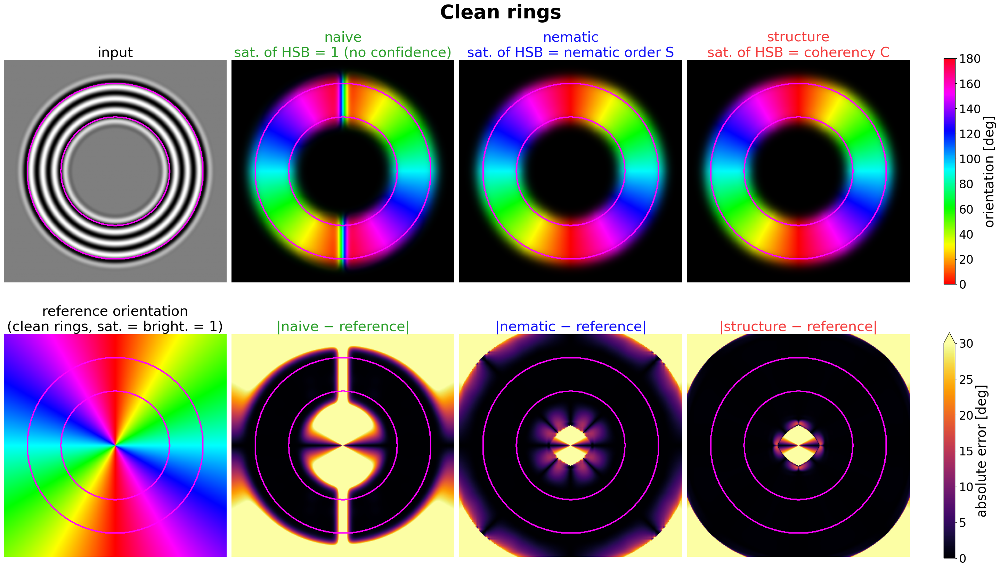

low     (ρ_sat = 0.4, σ_noise = 0.005, β_ramp = 0.01) -> images/ring_lownoise.tif: naive MAE = 16.43°, nematic MAE = 4.65°, structure MAE = 0.35°


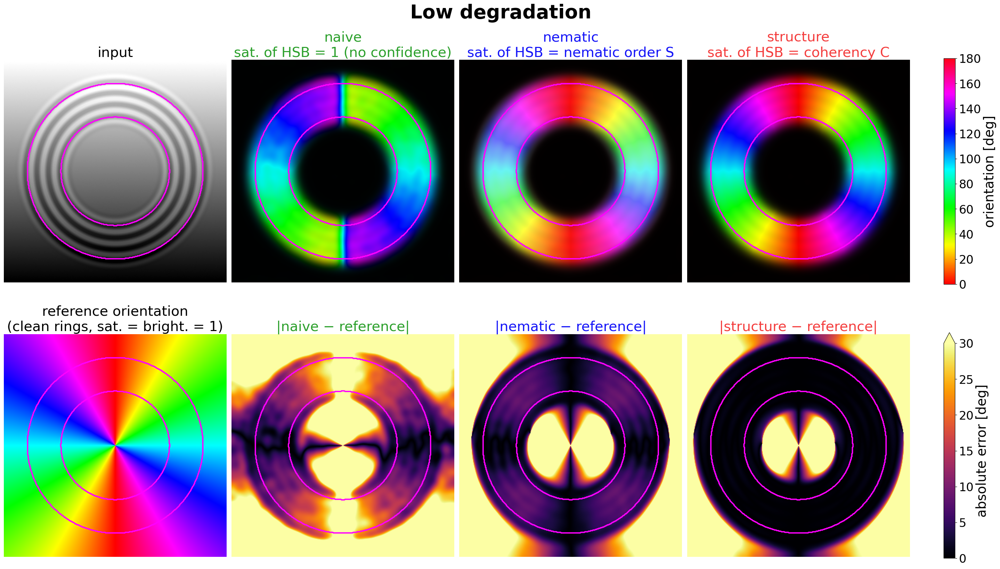

medium  (ρ_sat = 0.6, σ_noise = 0.015, β_ramp = 0.02) -> images/ring_mednoise.tif: naive MAE = 25.08°, nematic MAE = 8.68°, structure MAE = 0.64°


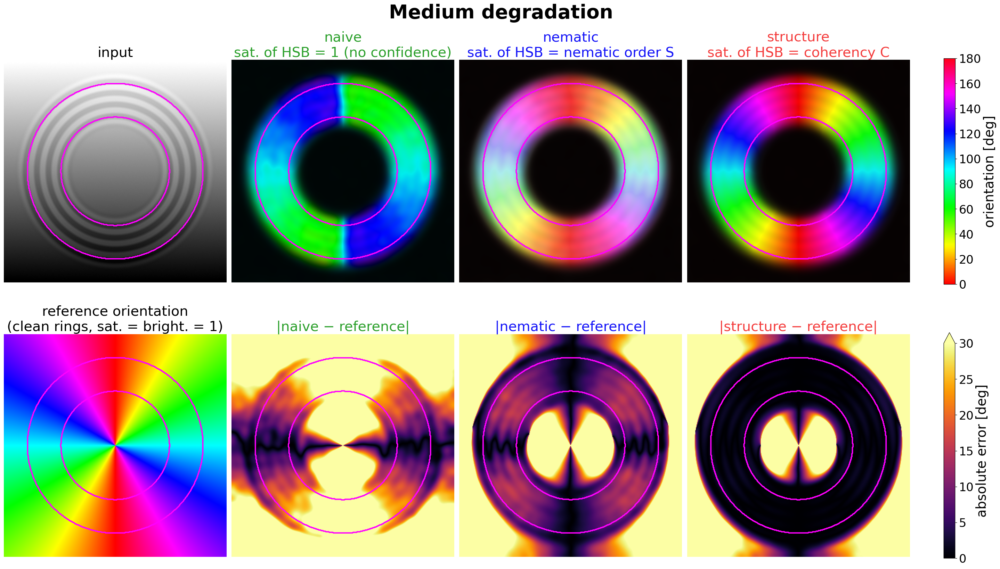

high    (ρ_sat = 0.8, σ_noise = 0.025, β_ramp = 0.05) -> images/ring_highnoise.tif: naive MAE = 33.39°, nematic MAE = 34.22°, structure MAE = 1.67°


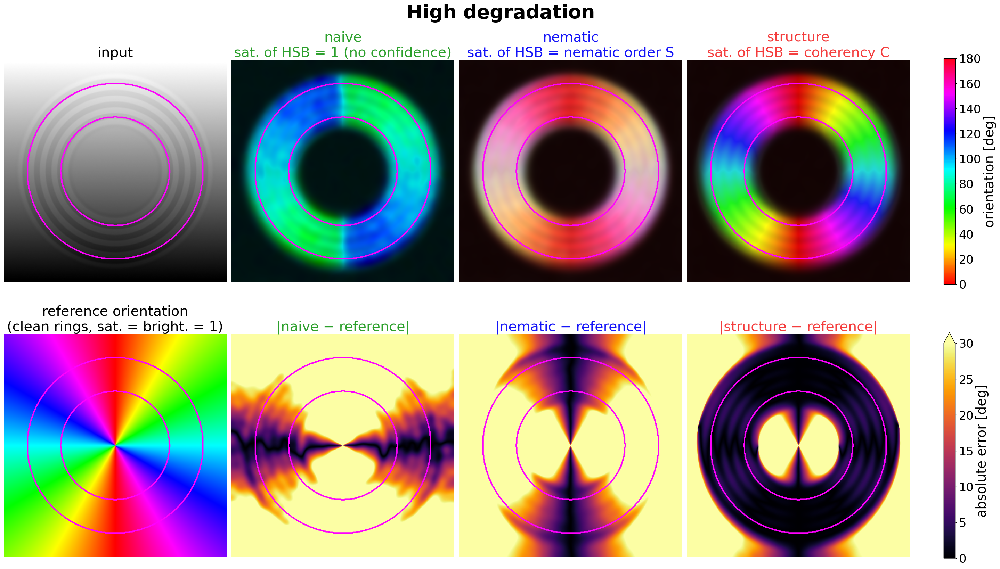

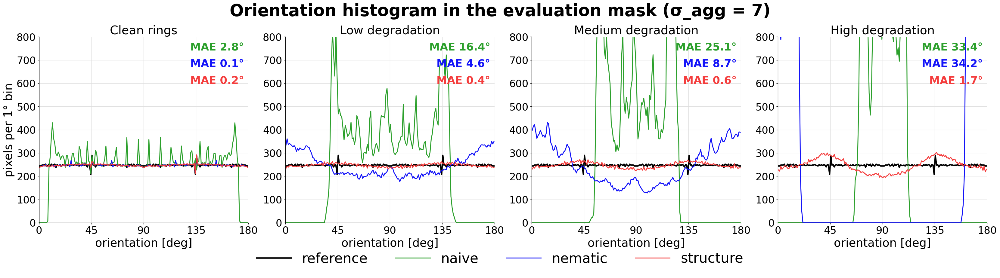

In [112]:
TIFF_NAMES = {'none': 'ring_noiseless', 'low': 'ring_lownoise', 'medium': 'ring_mednoise', 'high': 'ring_highnoise'}

level_images = {level: degraded_image(level) for level in LEVELS}
level_analyses = {level: analyze(data) for level, data in level_images.items()}

for level, data in level_images.items():
    path = save_image_tiff(data['image'], TIFF_NAMES[level])
    print(f'{level:7s} ({degradation_label(data)}) -> {path}: ' +
          ', '.join(f'{name} MAE = {level_analyses[level]["mae"][name]:.2f}°' for name in ESTIMATOR_NAMES))
    plot_maps(data, level_analyses[level], LEVEL_TITLES[level], f'ring_maps_{level}.png')

fig, axes = plt.subplots(1, 4, figsize=FIGSIZE_HISTOGRAMS, constrained_layout=True)
pad_layout(fig, **PAD)
for ax, level in zip(axes, LEVELS):
    plot_orientation_histogram(ax, level_analyses[level], LEVEL_TITLES[level])
axes[0].set_ylabel(f'pixels per {ANGLE_BIN:g}° bin')
add_figure_legend(fig, axes[0])
fig.suptitle(f'Orientation histogram in the evaluation mask (σ_agg = {DEFAULT_SIGMA:g})')
fig.savefig(RESULTS / 'ring_levels_histogram.png', dpi=150, bbox_inches='tight')
fig.savefig(RESULTS / 'ring_levels_histogram.jpg', dpi=150, bbox_inches='tight')
plt.show()

## 2. Effect of the saturation

$\rho_{\mathrm{sat}}$ varies; noise and ramp stay low. In all sweep figures: top, inputs; middle, orientation histograms of the two tensors inside the evaluation mask; bottom, absolute error, $S$ and $C$, and energy $E$ versus the swept parameter (mean $\pm$ std, filled markers; median, hollow markers). The naive mean is left out.

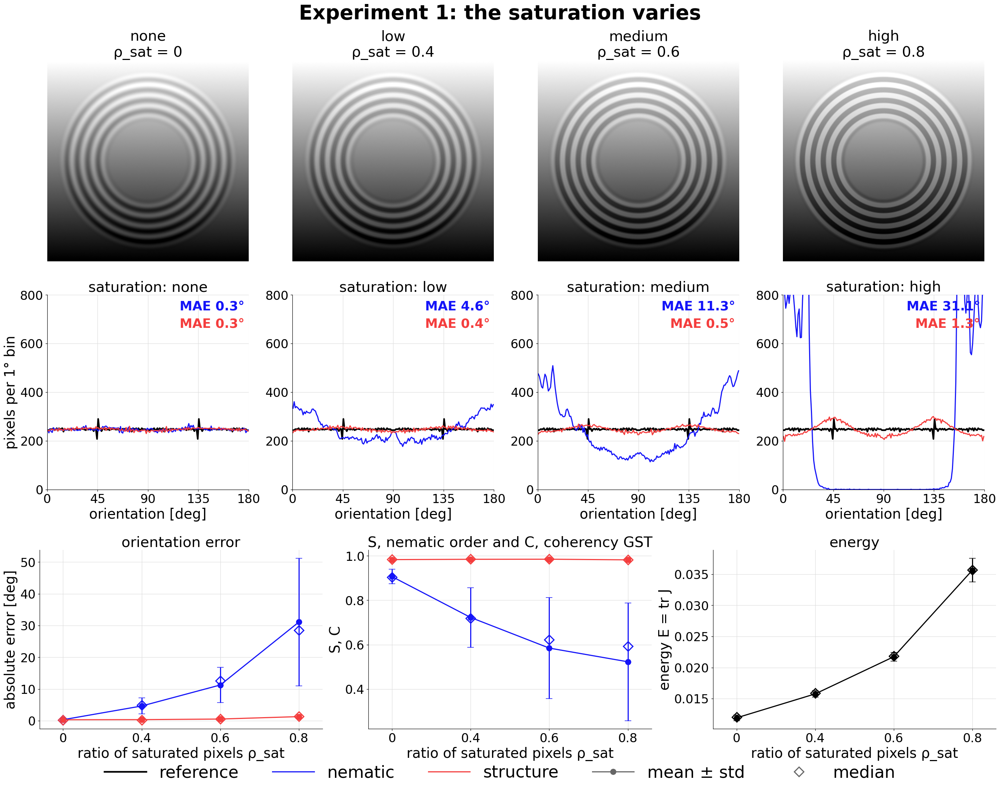

In [106]:
saturation_images = [degraded_image(saturation=level) for level in LEVELS]
saturation_analyses = [analyze(data) for data in saturation_images]

plot_sweep(images=[data['image'] for data in saturation_images],
           image_titles=[f'{level}\nρ_sat = {SATURATION_RATIO[level]:g}' for level in LEVELS],
           analyses=saturation_analyses,
           histogram_titles=[f'saturation: {level}' for level in LEVELS],
           suptitle='Experiment 1: the saturation varies',
           filename='ring_sweep_saturation.png',
           sweep_values=[SATURATION_RATIO[level] for level in LEVELS],
           sweep_label='ratio of saturated pixels ρ_sat')

## 3. Effect of the Gaussian noise

$\sigma_{\mathrm{noise}}$ varies; saturation and ramp stay low.

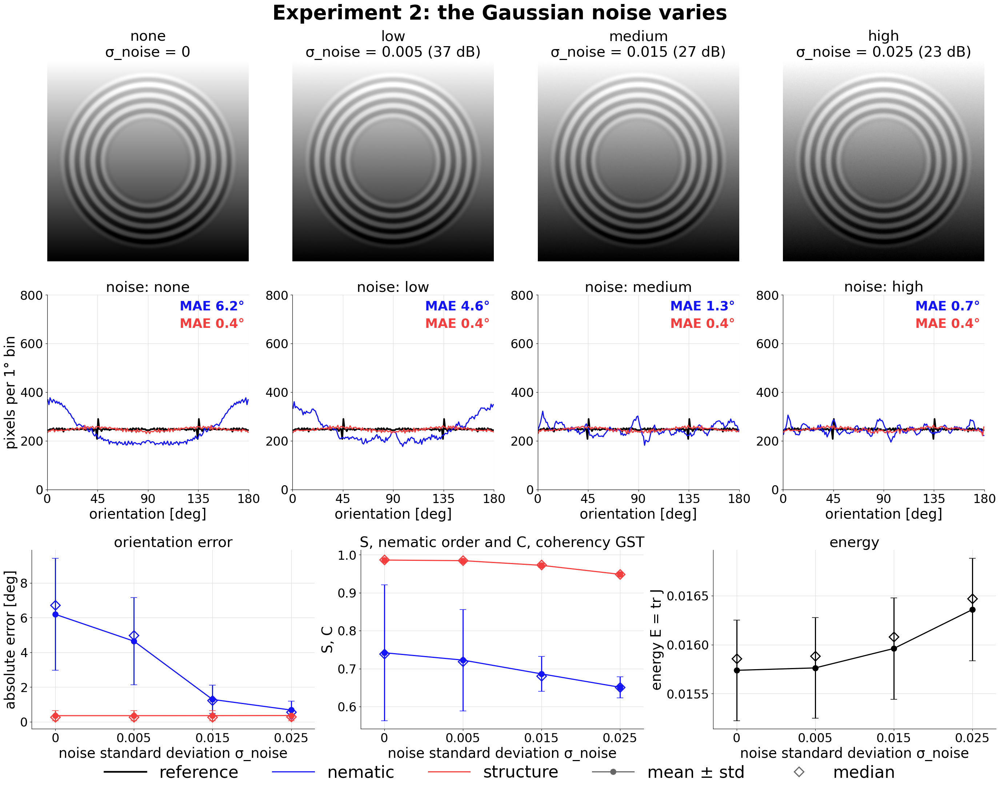

In [107]:
noise_images = [degraded_image(noise=level) for level in LEVELS]
noise_analyses = [analyze(data) for data in noise_images]

plot_sweep(images=[data['image'] for data in noise_images],
           image_titles=[f'{level}\nσ_noise = {NOISE[level]:g}' + (f' ({snr_db_from_noise(NOISE[level]):.0f} dB)' if NOISE[level] > 0 else '')
                       for level in LEVELS],
           analyses=noise_analyses,
           histogram_titles=[f'noise: {level}' for level in LEVELS],
           suptitle='Experiment 2: the Gaussian noise varies',
           filename='ring_sweep_noise.png',
           sweep_values=[NOISE[level] for level in LEVELS],
           sweep_label='noise standard deviation σ_noise')

## 4. Effect of the ramp

$\beta_{\mathrm{ramp}}$ varies; saturation and noise stay low.

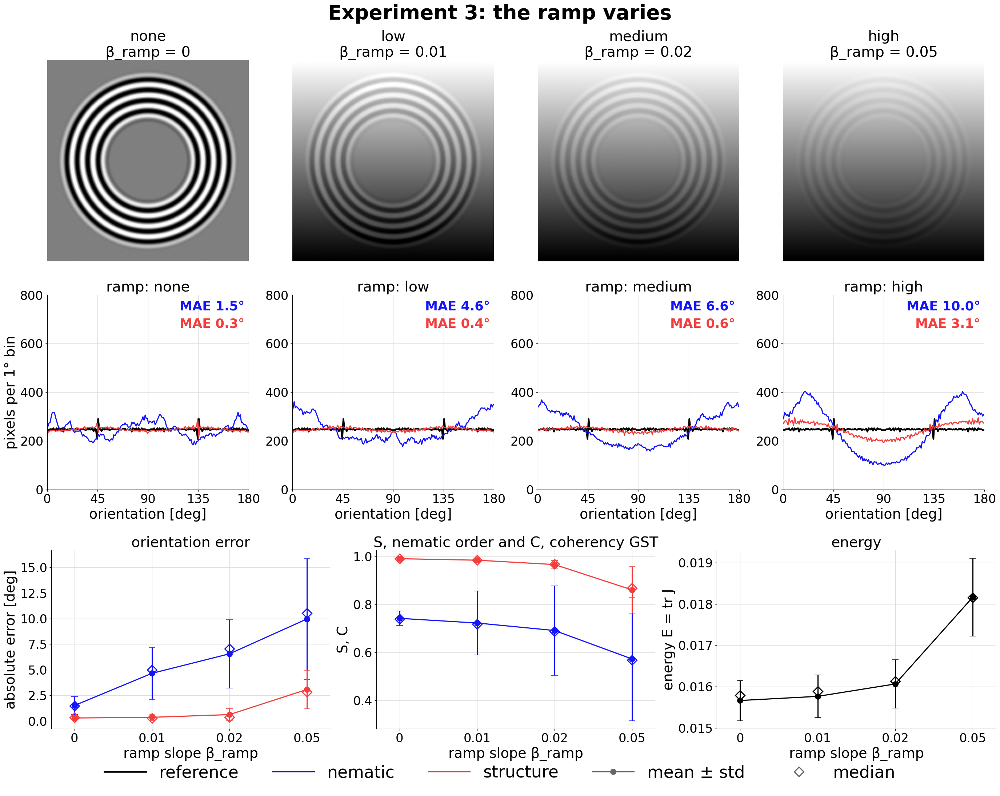

In [108]:
ramp_images = [degraded_image(ramp=level) for level in LEVELS]
ramp_analyses = [analyze(data) for data in ramp_images]

plot_sweep(images=[data['image'] for data in ramp_images],
           image_titles=[f'{level}\nβ_ramp = {RAMP[level]:g}' for level in LEVELS],
           analyses=ramp_analyses,
           histogram_titles=[f'ramp: {level}' for level in LEVELS],
           suptitle='Experiment 3: the ramp varies',
           filename='ring_sweep_ramp.png',
           sweep_values=[RAMP[level] for level in LEVELS],
           sweep_label='ramp slope β_ramp')

## 5. Effect of the shot noise

$\lambda_{\mathrm{shot}}$ varies; saturation, Gaussian noise and ramp stay low.

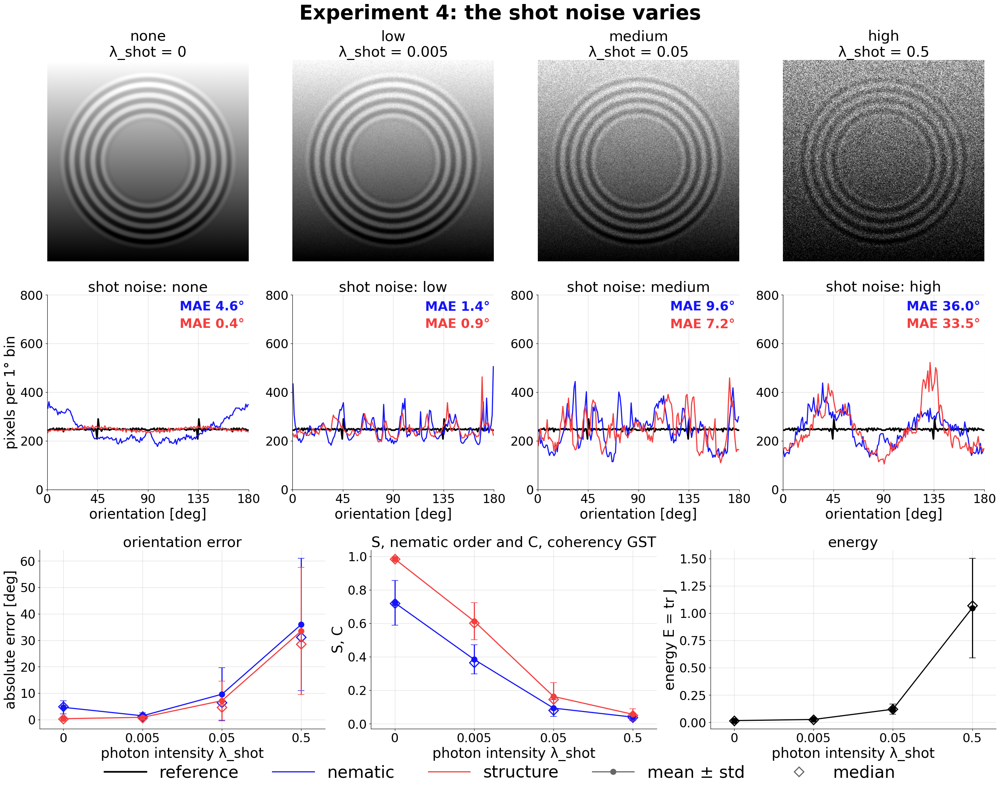

In [109]:
shot_images = [degraded_image(shot=level) for level in LEVELS]
shot_analyses = [analyze(data) for data in shot_images]

plot_sweep(images=[data['image'] for data in shot_images],
           image_titles=[f'{level}\nλ_shot = {SHOT[level]:g}' for level in LEVELS],
           analyses=shot_analyses,
           histogram_titles=[f'shot noise: {level}' for level in LEVELS],
           suptitle='Experiment 4: the shot noise varies',
           filename='ring_sweep_shot.png',
           sweep_values=[SHOT[level] for level in LEVELS],
           sweep_label='photon intensity λ_shot')

## 6. Effect of the speckle noise

$\rho_{\mathrm{sp}}$ varies; saturation, Gaussian noise and ramp stay low.

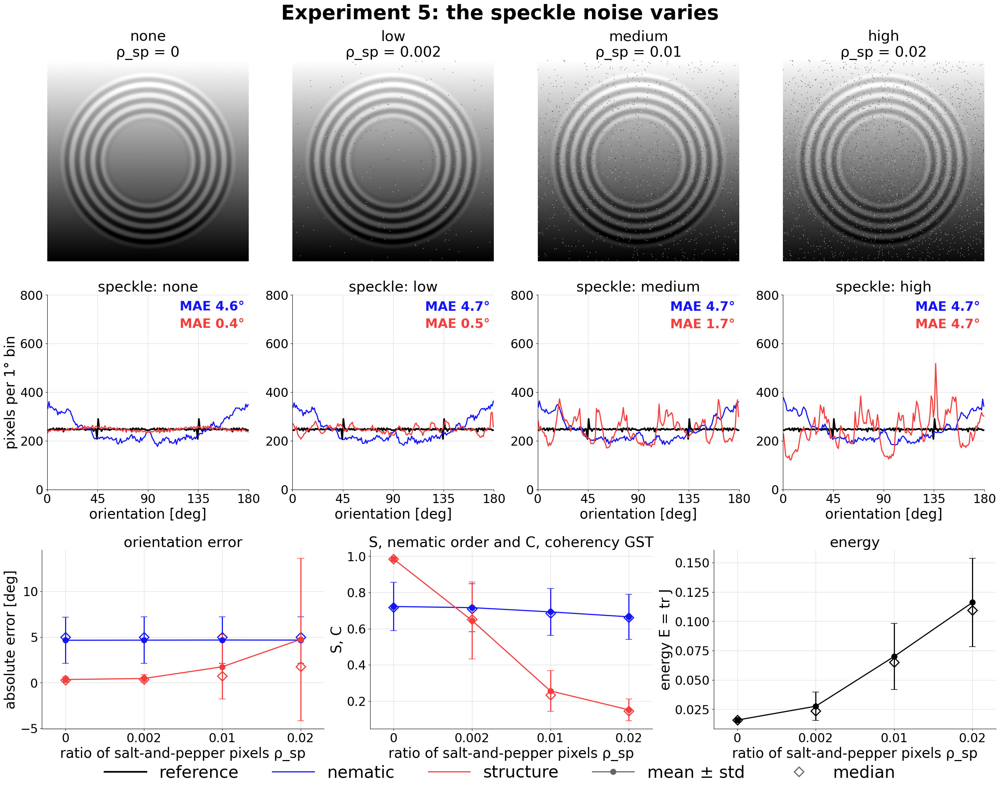

In [110]:
speckle_images = [degraded_image(speckle=level) for level in LEVELS]
speckle_analyses = [analyze(data) for data in speckle_images]

plot_sweep(images=[data['image'] for data in speckle_images],
           image_titles=[f'{level}\nρ_sp = {SPECKLE[level]:g}' for level in LEVELS],
           analyses=speckle_analyses,
           histogram_titles=[f'speckle: {level}' for level in LEVELS],
           suptitle='Experiment 5: the speckle noise varies',
           filename='ring_sweep_speckle.png',
           sweep_values=[SPECKLE[level] for level in LEVELS],
           sweep_label='ratio of salt-and-pepper pixels ρ_sp')

## 7. Effect of the Gaussian window $\sigma_{\mathrm{agg}}$

All degradations at their baseline. The top row shows a $96\times96$ px crop of the input with the window (circles of radius $\sigma_{\mathrm{agg}}$ and $2\sigma_{\mathrm{agg}}$), to compare with the ring period $T=20$ px.

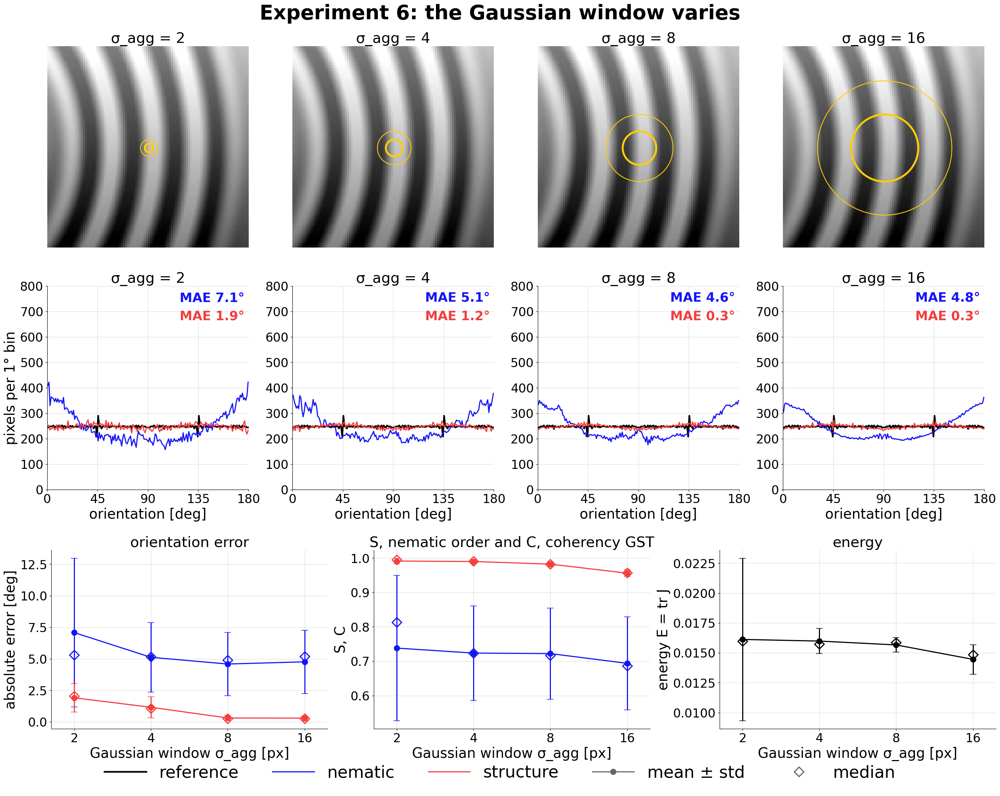

In [111]:
SIGMA_LIST = [2.0, 4.0, 8.0, 16.0]   # px

ring = degraded_image()   # every degradation at its BASELINE level
sigma_analyses = [analyze(ring, sigma_agg=s) for s in SIGMA_LIST]

plot_sweep(images=[ring_crop(ring)] * len(SIGMA_LIST),
           image_titles=[f'σ_agg = {s:g}' for s in SIGMA_LIST],
           analyses=sigma_analyses,
           histogram_titles=[f'σ_agg = {s:g}' for s in SIGMA_LIST],
           suptitle='Experiment 6: the Gaussian window varies',
           filename='ring_sweep_gauss_sigma.png',
           sweep_values=SIGMA_LIST,
           sweep_label='Gaussian window σ_agg [px]',
           overlays=[window_overlay(sigma_agg=s) for s in SIGMA_LIST])